In [1]:
# Limit number of cores
import os
os.nice(19)
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

# Create logger
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.hasHandlers():
    ch = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    ch.setFormatter(formatter)
    logger.addHandler(ch)

In [2]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
import h5py

rootpath = '/home/dneup16/leiden_phd/scripts/GNAT'
if rootpath not in os.sys.path:
    os.sys.path.append(rootpath)

import src.galaxy_alignment_prediction_tool.multipoles
import src.galaxy_alignment_prediction_tool.powerspectrum
import src.galaxy_alignment_prediction_tool.projections
import src.galaxy_alignment_prediction_tool.fitter
import src.galaxy_alignment_prediction_tool.utils

# Reload to update changes
import importlib
importlib.reload(src.galaxy_alignment_prediction_tool.multipoles)
importlib.reload(src.galaxy_alignment_prediction_tool.powerspectrum)
importlib.reload(src.galaxy_alignment_prediction_tool.projections)
importlib.reload(src.galaxy_alignment_prediction_tool.fitter)
importlib.reload(src.galaxy_alignment_prediction_tool.utils)

from src.galaxy_alignment_prediction_tool.multipoles import multipoles
from src.galaxy_alignment_prediction_tool.powerspectrum import powerSpectrum
from src.galaxy_alignment_prediction_tool.projections import projections
from src.galaxy_alignment_prediction_tool.fitter import fitter
from src.galaxy_alignment_prediction_tool.utils import ioUtils

# Initialise classes
fitterHandler = fitter(logger=logger)
ioUtilsHandler = ioUtils(logger=logger)
powerSpectrumHandler = powerSpectrum()
multipolesHandler = multipoles()
projectionsHandler = projections()

# Initialise cosmology and calculate predictions

In [3]:
# Initialise cosmology
cosmo_dict = {
	'h': 0.681,
	'Omega_c': 0.256011,
	'Omega_b': 0.0486,
    'm_nu': [0.06, 0.0, 0.0],
    'mass_split': 'list',
	'A_s': 2.099e-9,
	'n_s': 0.967,
}
k_input = np.geomspace(1e-5, 500, 1000)
cosmology = ccl.Cosmology(**cosmo_dict)

# Specify projection parameters
rmin = 0.1/cosmo_dict['h']  # [Mpc]
rmax = 50./cosmo_dict['h']  # [Mpc]
num_r = 50
pi_max = 50./cosmo_dict['h']  # [Mpc]
rp = np.geomspace(rmin, rmax, num_r)
pimax = pi_max
# Correlation functions per reshift
redshift_list = [0., 0.5, 1., 1.5, 2., 2.5]

r_redshift_list_model = []
rp_redshift_list_model = []
projections_redshift_list_model = []
multipoles_redshift_list_model = []

for redshift in redshift_list:
    pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
        cosmo=cosmology,
        k_input=k_input,
        redshift=redshift,
        pk_type='nonlinear_matter'
    )

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_ccl,
        cosmo=cosmology,
        redshift=redshift
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_ccl,
        cosmo=cosmology,
        redshift=redshift,
    )

    # Create splines
    pkgp_spline = powerSpectrumHandler.power_spectrum_spline(
        k_input=k_input,
        pk_input=pkgp,
    )
    pkgg_spline = powerSpectrumHandler.power_spectrum_spline(
        k_input=k_input,
        pk_input=pkgg,
    )

    # Calculate multipoles
    r_xigp_list, xigp_list, ells_gp = multipolesHandler.return_all_multipoles_from_power_spectrum(
        power_spectrum_spline=pkgp_spline,
        probe_type='g+',
    )

    r_xigg_list, xigg_list, ells_gg = multipolesHandler.return_all_multipoles_from_power_spectrum(
        power_spectrum_spline=pkgg_spline,
        probe_type='gg',
    )

    # Calculate projections
    w_gp = projectionsHandler.convert_multipoles_to_projected_correlation_function(
        r_list=r_xigp_list,
        xi_ell_list=xigp_list,
        ell_list=ells_gp,
        spin=2,
        rp_array=rp,
        pi_max=pimax,
    )

    w_gg = projectionsHandler.convert_multipoles_to_projected_correlation_function(
        r_list=r_xigg_list,
        xi_ell_list=xigg_list,
        ell_list=ells_gg,
        spin=0,
        rp_array=rp,
        pi_max=pimax,
    )

    # Append to array, use only non-zero contributions
    r_redshift_list_model.append([r_xigg_list[0], r_xigp_list[0]])
    rp_redshift_list_model.append([rp, rp])
    
    projections_redshift_list_model.append([w_gg, w_gp])
    multipoles_redshift_list_model.append([xigg_list[0], xigp_list[0]])

## Plot unscaled predictions results

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, redshift in enumerate(redshift_list):
    ax[0].semilogx(
        rp_redshift_list_model[i][1],
        rp_redshift_list_model[i][1]*projections_redshift_list_model[i][1],
        label=f'z={redshift}',
    )

    ax[1].semilogx(
        r_redshift_list_model[i][1],
        r_redshift_list_model[i][1]**2*multipoles_redshift_list_model[i][1],
        label=f'z={redshift}',
    )
ax[0].set_xlabel('rp [Mpc]')
ax[0].set_ylabel('rp*w_gp [Mpc]^2')
ax[1].set_xlabel('r [Mpc]')
ax[1].set_ylabel('r^2*xi_gp [Mpc]^2')
for ax_ in ax:
    ax_.legend()
    ax_.set_xlim(0.1, 50)
plt.legend()
savepath_gp = '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/gp_redshift_dependency_predictions_only.png'
plt.savefig(savepath_gp, dpi=200, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, redshift in enumerate(redshift_list):
    ax[0].semilogx(
        rp_redshift_list_model[i][0],
        rp_redshift_list_model[i][0]*projections_redshift_list_model[i][0],
        label=f'z={redshift}',
    )

    ax[1].semilogx(
        r_redshift_list_model[i][0],
        r_redshift_list_model[i][0]**2*multipoles_redshift_list_model[i][0],
        label=f'z={redshift}',
    )
ax[0].set_xlabel('rp [Mpc]')
ax[0].set_ylabel('rp*w_gg [Mpc]^2')
ax[1].set_xlabel('r [Mpc]')
ax[1].set_ylabel('r^2*xi_gg [Mpc]^2')
for ax_ in ax:
    ax_.legend()
    ax_.set_xlim(rmin, rmax)
plt.legend()
savepath_gg = '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/gg_redshift_dependency_predictions_only.png'
plt.savefig(savepath_gg, dpi=200, bbox_inches='tight')
plt.close()

logger.info(f'Saved gp plot to {savepath_gp}')
logger.info(f'Saved gg plot to {savepath_gg}')

2026-01-23 11:08:20,569 - __main__ - INFO - Saved gp plot to /home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/gp_redshift_dependency_predictions_only.png
2026-01-23 11:08:20,570 - __main__ - INFO - Saved gg plot to /home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/gg_redshift_dependency_predictions_only.png


# Load marloes data

In [5]:
def return_data_from_h5py(
    path_to_h5py,
):

    redshifts = {
        'L400_m7': {'Snapshot_127': 0, 'Snapshot_102': 0.5, 'Snapshot_92': 1, 'Snapshot_84': 1.5, 'Snapshot_76': 2, 'Snapshot_68': 2.5},
        'TNG300': {'Snapshot_33': 2.0, 'Snapshot_39': 1.53, 'Snapshot_40': 1.5, 'Snapshot_50': 1., 'Snapshot_67': 0.5, 'Snapshot_99': 0.}
    }

    rp_redshift_list_data = []
    projections_redshift_list_data = []
    projections_cov_redshift_list_data = []

    r_redshift_list_data = []
    multipoles_redshift_list_data = []
    multipoles_cov_redshift_list_data = []

    with h5py.File(path_to_h5py, 'r') as hf:
        for snapshot in redshifts.keys():

            # Load projections
            rp_redshift_list_data.append([
                hf['L400_m7'][snapshot]['w_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_rp'][:]/cosmo_dict['h'],
                hf['L400_m7'][snapshot]['w_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_rp'][:]/cosmo_dict['h'],
            ])
            projections_redshift_list_data.append([
                hf['L400_m7'][snapshot]['w_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz'][:]/cosmo_dict['h'],
                hf['L400_m7'][snapshot]['w_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz'][:]/cosmo_dict['h'],
            ])
            projections_cov_redshift_list_data.append([
                hf['L400_m7'][snapshot]['w_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'][:,:]/cosmo_dict['h']**2,
                hf['L400_m7'][snapshot]['w_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'][:,:]/cosmo_dict['h']**2,
            ])

            r_redshift_list_data.append([
                hf['L400_m7'][snapshot]['multipoles_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_r'][:]/cosmo_dict['h'],
                hf['L400_m7'][snapshot]['multipoles_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_r'][:]/cosmo_dict['h'],
            ])
            multipoles_redshift_list_data.append([
                hf['L400_m7'][snapshot]['multipoles_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz'][:],
                hf['L400_m7'][snapshot]['multipoles_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz'][:],
            ])
            multipoles_cov_redshift_list_data.append([
                hf['L400_m7'][snapshot]['multipoles_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'][:],
                hf['L400_m7'][snapshot]['multipoles_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'][:],
            ])

    return (
        rp_redshift_list_data, 
        projections_redshift_list_data, 
        projections_cov_redshift_list_data,
        r_redshift_list_data, 
        multipoles_redshift_list_data, 
        multipoles_cov_redshift_list_data
    )

def zeropad_covariance_matrix(top_left, bottom_right):
    zero_crosscovar = np.zeros((top_left.shape[0], bottom_right.shape[1]))
    full_covariance = np.block([
        [top_left, zero_crosscovar],
        [zero_crosscovar.T, bottom_right],
    ])
    return full_covariance

In [6]:
path_to_h5py = '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/run_20260120/IA_data_modeling_z_evolution_stars.hdf5'

measurement_dict = ioUtilsHandler.load_h5_recursive(
    file_path=path_to_h5py
)

In [8]:
for sim in measurement_dict.keys():
    print(f'Simulation: {sim}')
    for snapshot in measurement_dict[sim].keys():
        print(f'  Snapshot: {snapshot}')

print('Data strings L400_m7:')
print(list(measurement_dict['L400_m7']['Snapshot_102']['w_gg'].keys()))

print('Data strings TNG300:')
print(list(measurement_dict['TNG300']['Snapshot_67']['w_gg'].keys()))

Simulation: L400_m7
  Snapshot: Snapshot_102
  Snapshot: Snapshot_127
  Snapshot: Snapshot_68
  Snapshot: Snapshot_76
  Snapshot: Snapshot_84
  Snapshot: Snapshot_92
Simulation: TNG300
  Snapshot: Snapshot_50
  Snapshot: Snapshot_67
  Snapshot: Snapshot_99
Data strings L400_m7:
['D_nstar_gt50_S_mstar_gt9p27_LOSy', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_D_nstar_gt50_S_mstar_gt9p27_LOSz', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_D_nstar_gt50_S_mstar_gt9p27_LOSz_cov', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_D_nstar_gt50_S_mstar_gt9p27_LOSz_rp', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_D_nstar_gt50_S_nstar_gt50_LOSz', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_D_nstar_gt50_S_nstar_gt50_LOSz_cov', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_D_nstar_gt50_S_nstar_gt50_LOSz_rp', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_cov', 'D_nstar_gt50_S_mstar_gt9p27_LOSy_rp', 'D_nstar_gt50_S_mstar_gt9p27_LOSz', 'D_nstar_gt50_S_mstar_gt9p27_LOSz_cov', 'D_nstar_gt50_S_mstar_gt9p27_LOSz_rp', 'D_nstar_gt50_S_mstar_gt9p27_mDM_gt11p34_LOSy', 'D_nstar_gt50_S_msta

In [7]:
data_str = 'D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz'

redshifts = {
    'L400_m7': {'Snapshot_127': 0, 'Snapshot_102': 0.5, 'Snapshot_92': 1, 'Snapshot_84': 1.5, 'Snapshot_76': 2, 'Snapshot_68': 2.5},
    'TNG300': {'Snapshot_33': 2.0, 'Snapshot_39': 1.53, 'Snapshot_40': 1.5, 'Snapshot_50': 1., 'Snapshot_67': 0.5, 'Snapshot_99': 0.}
}


for sim in measurement_dict.keys():
    for snapshot in measurement_dict[sim].keys():
        redshift_sim = redshifts[sim]
        
        will_analyse = ioUtilsHandler.is_in_snapshot_dict(
            snapshot_dict=redshift_sim,
            key=snapshot,
        )

        if will_analyse:
            logger.info(f'Analysing simulation {sim}, snapshot {snapshot} at redshift {redshift_sim[snapshot]}')
            # print(measurement_dict[sim][snapshot]['w_gg'].keys())
            try:
                rp_gg_data = measurement_dict[sim][snapshot]['w_gg'][data_str + '_rp']/cosmo_dict['h']
                w_gg_data = measurement_dict[sim][snapshot]['w_gg'][data_str]/cosmo_dict['h']
                w_gg_cov_data = measurement_dict[sim][snapshot]['w_gg'][data_str + '_cov']/cosmo_dict['h']**2

                rp_gplus_data = measurement_dict[sim][snapshot]['w_g_plus'][data_str + '_rp']/cosmo_dict['h']
                w_gplus_data = measurement_dict[sim][snapshot]['w_g_plus'][data_str]/cosmo_dict['h']
                w_gplus_cov_data = measurement_dict[sim][snapshot]['w_g_plus'][data_str + '_cov']/cosmo_dict['h']**2

                r_gg_data = measurement_dict[sim][snapshot]['multipoles_gg'][data_str + '_r']/cosmo_dict['h']
                xi_gg_data = measurement_dict[sim][snapshot]['multipoles_gg'][data_str]
                xi_gg_cov_data = measurement_dict[sim][snapshot]['multipoles_gg'][data_str + '_cov']/cosmo_dict['h']**2

                r_gplus_data = measurement_dict[sim][snapshot]['multipoles_g_plus'][data_str + '_r']/cosmo_dict['h']
                xi_gplus_data = measurement_dict[sim][snapshot]['multipoles_g_plus'][data_str]
                xi_gplus_cov_data = measurement_dict[sim][snapshot]['multipoles_g_plus'][data_str + '_cov']/cosmo_dict['h']**2

            except KeyError as e:
                logger.warning(f'Could not extract all data for simulation {sim}, snapshot {snapshot}: {e}')
                logger.warning('Skipping to next snapshot.')
                continue

            

2025-12-08 14:12:33,668 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_102 at redshift 0.5
2025-12-08 14:12:33,669 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_127 at redshift 0
2025-12-08 14:12:33,671 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_68 at redshift 2.5
2025-12-08 14:12:33,672 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_76 at redshift 2
2025-12-08 14:12:33,673 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_84 at redshift 1.5
2025-12-08 14:12:33,673 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_92 at redshift 1
2025-12-08 14:12:33,674 - __main__ - INFO - Analysing simulation TNG300, snapshot Snapshot_33 at redshift 2.0
2025-12-08 14:12:33,675 - __main__ - INFO - Analysing simulation TNG300, snapshot Snapshot_39 at redshift 1.53
2025-12-08 14:12:33,676 - __main__ - INFO - Analysing simulation TNG300, snapshot Snapshot_40 at redshift 1.5
2025-12

In [8]:
path_to_h5py = '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/IA_data_modeling_z_evolution.hdf5'

colibre_data = return_data_from_h5py(
    path_to_h5py=path_to_h5py,
)
rp_redshift_list_colibre, projections_redshift_list_colibre, projections_cov_redshift_list_colibre, r_redshift_list_colibre, multipoles_redshift_list_colibre, multipoles_cov_redshift_list_colibre = colibre_data

# Fill up off diagonals with zeros
multipoles_cov_redshift_list_colibre_padded = []
for multipoles_cov in multipoles_cov_redshift_list_colibre:
    top_left = multipoles_cov[0]
    bottom_right = multipoles_cov[1]
    multipoles_cov = zeropad_covariance_matrix(top_left, bottom_right)
    multipoles_cov_redshift_list_colibre_padded.append(
        zeropad_covariance_matrix(top_left, bottom_right)
    )

projections_cov_redshift_list_colibre_padded = []
for projections_cov in projections_cov_redshift_list_colibre:
    top_left = projections_cov[0]
    bottom_right = projections_cov[1]
    projections_cov = zeropad_covariance_matrix(top_left, bottom_right)
    projections_cov_redshift_list_colibre_padded.append(
        zeropad_covariance_matrix(top_left, bottom_right)
    )

KeyError: "Unable to synchronously open object (object 'L400_m7' doesn't exist)"

### Graveyard

In [16]:
redshifts = {
    'L400_m7': {'Snapshot_127': 0, 'Snapshot_102': 0.5, 'Snapshot_92': 1, 'Snapshot_84': 1.5, 'Snapshot_76': 2, 'Snapshot_68': 2.5},
    'TNG300': {'Snapshot_33': 2.0, 'Snapshot_39': 1.53, 'Snapshot_40': 1.5, 'Snapshot_50': 1., 'Snapshot_67': 0.5, 'Snapshot_99': 0.}
}

conversion = {
    'S_nstar_gt50': 'g',
    'D_nstar_gt50': 'g',
    'S_nstar_gt300': 'p',
}
test_str1 = 'D_nstar_gt50_S_nstar_gt50_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'
test_str2 = 'D_nstar_gt50_S_nstar_gt50_LOSy_D_nstar_gt50_S_nstar_gt300_LOSy_cov'

test_str3 = 'D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'
test_str4 = 'D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSy_cov'

test_str5 = 'D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'
test_str6 = 'D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSy_cov'

for sim in measurement_dict.keys():
    for snapshot in measurement_dict[sim].keys():
        redshift_sim = redshifts[sim]
        
        will_analyse = ioUtilsHandler.is_in_snapshot_dict(
            snapshot_dict=redshift_sim,
            key=snapshot,
        )

        if will_analyse:
            logger.info(f'Analysing simulation {sim}, snapshot {snapshot} at redshift {redshift_sim[snapshot]}')
            # Extract data
            try:
                # for key in measurement_dict[sim][snapshot]['w_g_plus_w_gg'].keys():
                    # print(np.shape(measurement_dict[sim][snapshot]['w_g_plus_w_gg'][key]))
                    # for conv in conversion.keys():
                    #     key = key.replace(conv, conversion[conv])
                    # print(key)
                cov1 = measurement_dict[sim][snapshot]['w_g_plus_w_gg'][test_str1][:15,15:]
                cov2 = measurement_dict[sim][snapshot]['w_g_plus_w_gg'][test_str2]

                cov3 = measurement_dict[sim][snapshot]['w_g_plus_w_gg'][test_str3]
                cov4 = measurement_dict[sim][snapshot]['w_g_plus_w_gg'][test_str4]

                cov5 = measurement_dict[sim][snapshot]['w_g_plus'][test_str5][:15,:15]
                cov6 = measurement_dict[sim][snapshot]['w_g_plus'][test_str6]

                print(np.allclose(cov1, cov2, rtol=1e-2, atol=1e-2))
                # print(np.allclose(cov3, cov4, rtol=1e-2, atol=1e-2))
                # print(np.allclose(cov3, cov4))
                    
                rp_gg_data = measurement_dict[sim][snapshot]['w_gg']['D_nstar_gt50_S_nstar_gt50_LOSy_D_nstar_gt50_S_nstar_gt50_LOSz_rp']/cosmo_dict['h']
            #     wgg_data = measurement_dict[sim][snapshot]['w_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz']/cosmo_dict['h']
            #     wgg_cov_data = measurement_dict[sim][snapshot]['w_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov']/cosmo_dict['h']**2

            #     rp_gp_data = measurement_dict[sim][snapshot]['w_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_rp']/cosmo_dict['h']
            #     wgp_data = measurement_dict[sim][snapshot]['w_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz']/cosmo_dict['h']
            #     wgp_cov_data = measurement_dict[sim][snapshot]['w_g_plus']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov']/cosmo_dict['h']**2

            #     print(measurement_dict[sim][snapshot]['w_g_plus_w_gg'].keys())
            #     wgp_cross_wgg_cov_data = measurement_dict[sim][snapshot]['w_g_plus_w_gg']['D_nstar_gt50_S_nstar_gt300_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov']/cosmo_dict['h']**2
            #     wgp_cross_wgg_cov_data_alt = measurement_dict[sim][snapshot]['w_g_plus_w_gg']['D_nstar_gt50_S_nstar_gt300_LOSz_D_nstar_gt50_S_nstar_gt300_LOSz_cov']/cosmo_dict['h']**2
            #     print(np.shape(wgp_cross_wgg_cov_data_alt), np.shape(wgp_cross_wgg_cov_data))
            except KeyError as e:
                logger.warning(f'Could not extract all data for simulation {sim}, snapshot {snapshot}: {e}')
                logger.warning('Skipping to next snapshot.')
                continue



2025-12-08 14:13:52,405 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_102 at redshift 0.5
2025-12-08 14:13:52,407 - __main__ - WARNING - Could not extract all data for simulation L400_m7, snapshot Snapshot_102: 'D_nstar_gt50_S_nstar_gt50_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'
2025-12-08 14:13:52,409 - __main__ - WARNING - Skipping to next snapshot.
2025-12-08 14:13:52,410 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_127 at redshift 0
2025-12-08 14:13:52,412 - __main__ - WARNING - Could not extract all data for simulation L400_m7, snapshot Snapshot_127: 'D_nstar_gt50_S_nstar_gt50_LOSy_D_nstar_gt50_S_nstar_gt300_LOSz_cov'
2025-12-08 14:13:52,413 - __main__ - WARNING - Skipping to next snapshot.
2025-12-08 14:13:52,415 - __main__ - INFO - Analysing simulation L400_m7, snapshot Snapshot_68 at redshift 2.5
2025-12-08 14:13:52,417 - __main__ - WARNING - Could not extract all data for simulation L400_m7, snapshot Snapshot_68: 'D_nstar_gt50_S_nst

False
False
False
False
False


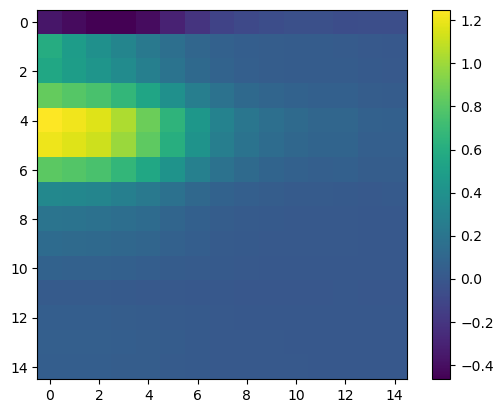

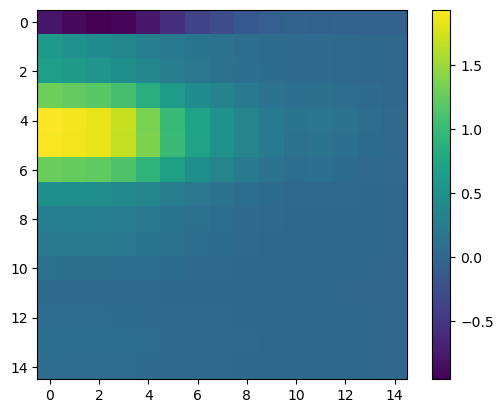

In [21]:
plt.imshow(cov1)
plt.colorbar()
plt.show()
plt.close()

plt.imshow(cov2)
plt.colorbar()
plt.show()
plt.close()

## Look at cross-covariance

In [5]:
path_to_h5py = '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/IA_data_modeling_z_evolution.hdf5'

with h5py.File(path_to_h5py, 'r') as hf:
    available_simulation = hf.keys()
    for simkey in available_simulation:
        for snapshot in hf[simkey].keys():
            print(simkey, snapshot, hf[simkey][snapshot].keys())

L400_m7 Snapshot_102 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_multipoles_gg', 'multipoles_gg', 'w_g_plus', 'w_g_plus_w_gg', 'w_gg']>
L400_m7 Snapshot_127 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_multipoles_gg', 'multipoles_gg', 'w_g_plus', 'w_g_plus_w_gg', 'w_gg']>
L400_m7 Snapshot_33 <KeysViewHDF5 ['w_g_plus']>
L400_m7 Snapshot_68 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_multipoles_gg', 'multipoles_gg', 'w_g_plus', 'w_g_plus_w_gg', 'w_gg']>
L400_m7 Snapshot_76 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_multipoles_gg', 'multipoles_gg', 'w_g_plus', 'w_g_plus_w_gg', 'w_gg']>
L400_m7 Snapshot_84 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_multipoles_gg', 'multipoles_gg', 'w_g_plus', 'w_g_plus_w_gg', 'w_gg']>
L400_m7 Snapshot_92 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_multipoles_gg', 'multipoles_gg', 'w_g_plus', 'w_g_plus_w_gg', 'w_gg']>
TNG300 Snapshot_33 <KeysViewHDF5 ['multipoles_g_plus', 'multipoles_g_plus_

# Run MCMCs

### Helper functions

In [26]:
from nautilus import Prior, Sampler
from getdist import plots, MCSamples

def produce_results_for_input_data(
    redshift_idx,
    r_data_list,
    data_list,
    r_model_list,
    model_list,
    cov_list,
    fitting_range: list = [10/cosmo_dict['h'], 50/cosmo_dict['h']],
    projection_type_list=['gg', 'gp'],
    renormalise_input=True,
    chi2_from_svd=True,
    n_jk=125,
):

    r_data_input = r_data_list[redshift_idx]
    data_input = data_list[redshift_idx]
    r_model_input = r_model_list[redshift_idx]
    model_input = model_list[redshift_idx]
    cov_input = cov_list[redshift_idx]

    def log_likelihood_all(params):
        A_IA = params['A_IA']
        b_g = params['b_g']

        chi2_total = fitterHandler.get_chi2_full_covariance(
            A_IA, 
            b_g, 
            r_data = r_data_input, 
            data = data_input, 
            r_model = r_model_input,
            model = model_input,
            cov = cov_input,
            fitting_range=fitting_range, 
            projection_type_list=projection_type_list,
            renormalise_input=renormalise_input,
            chi2_from_svd=chi2_from_svd,
            n_jk=n_jk,
        )

        return -0.5 * chi2_total

    prior = Prior()
    prior.add_parameter('A_IA', dist=(0, 20))
    prior.add_parameter('b_g', dist=(0, 10))

    sampler = Sampler(prior, log_likelihood_all, n_live=1000)
    sampler.run(verbose=True, discard_exploration=True)
    points, log_w, log_l = sampler.posterior()

    weights = np.exp(log_w - np.max(log_w))  # Normalize for numerical stability
    weights /= np.sum(weights)
    posterior_mean = np.average(points, axis=0, weights=weights)
    posterior_var = np.average((points - posterior_mean)**2, axis=0, weights=weights)
    posterior_std = np.sqrt(posterior_var)
    best_fit_paramsg = dict(zip(prior.keys, posterior_mean))

    print(best_fit_paramsg)
    print(posterior_std)

    ndim = points.shape[1]
    # Define names and labels programmatically (do this only once if they are same for all boxes)
    names = ['A_1', 'b_1']
    labels =['A_1', 'b_1']
    weights = np.exp(log_w - np.max(log_w))
    weights /= np.sum(weights)
    mcs = MCSamples(samples=points, names=names, labels=labels, weights=weights)
    outpath = f'/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/mcmc_output/colibre_IA_redshift{redshift_list[redshift_idx]:.1f}'
    mcs.saveAsText(outpath)

    import getdist

    mcs = getdist.loadMCSamples(outpath)
    g = plots.get_subplot_plotter()

    g.triangle_plot(
        mcs,
        labels,
        filled=False  # can be True, but might obscure overlaps
    )

    return best_fit_paramsg, posterior_std


def plot_best_fit_vs_data(
    redshift_idx,
    best_fit_paramsg,
    r_redshift_list_data,
    measurement_redshift_list_data,
    measurement_cov_redshift_list_data,
    r_redshift_list_model,
    measurement_redshift_list_model,
    fitting_range=[10/cosmo_dict['h'], 50/cosmo_dict['h']],
    r_scaling_for_plot=1
):

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # ---- Panel 1: gg ----
    best_fit_scaling_gg = best_fit_paramsg['b_g']**2
    ax[0].errorbar(
        r_redshift_list_data[redshift_idx][0],
        r_redshift_list_data[redshift_idx][0]**r_scaling_for_plot * measurement_redshift_list_data[redshift_idx][0],
        yerr = np.sqrt(np.diag(measurement_cov_redshift_list_data[redshift_idx][0])) * r_redshift_list_data[redshift_idx][0]**r_scaling_for_plot,
        fmt='o',
    )
    ax[0].plot(
        r_redshift_list_model[redshift_idx][0],
        r_redshift_list_model[redshift_idx][0]**r_scaling_for_plot * measurement_redshift_list_model[redshift_idx][0] * best_fit_scaling_gg,
        '-'
    )
    ax[0].set_title('gg projection')
    ax[0].set_xlabel('rp [Mpc]')
    ax[0].set_ylabel('rp * w_gg [Mpc]^2')

    # ---- Panel 2: gg ----
    best_fit_scaling_gp = best_fit_paramsg['A_IA'] * best_fit_paramsg['b_g']
    ax[1].errorbar(
        r_redshift_list_data[redshift_idx][1],
        r_redshift_list_data[redshift_idx][1]**r_scaling_for_plot * measurement_redshift_list_data[redshift_idx][1],
        yerr = np.sqrt(np.diag(measurement_cov_redshift_list_data[redshift_idx][1])) * r_redshift_list_data[redshift_idx][1]**r_scaling_for_plot,
        fmt='o',
    )
    ax[1].plot(
        r_redshift_list_model[redshift_idx][1],
        r_redshift_list_model[redshift_idx][1]**r_scaling_for_plot * measurement_redshift_list_model[redshift_idx][1] * best_fit_scaling_gp,
        '-'
    )
    ax[1].set_title('gp projection')
    ax[1].set_xlabel('rp [Mpc]')
    ax[1].set_ylabel('rp * w_gp [Mpc]^2')

    for idx, ax_ in enumerate(ax):
        xmin = 0.1
        xmax = 50
        ymin = 0.9*min(r_redshift_list_data[redshift_idx][idx]**r_scaling_for_plot * measurement_redshift_list_data[redshift_idx][idx])
        ymax = 1.1*max(r_redshift_list_data[redshift_idx][idx]**r_scaling_for_plot * measurement_redshift_list_data[redshift_idx][idx])
        ax_.fill_betweenx(
            y=[ymin, ymax],
            x1=[rmin,rmin],
            x2=[fitting_range[0], fitting_range[0]],
            color='gray',
            alpha=0.3,
            label='Fitting range'
        )
        ax_.set_xlim(rmin, rmax)
        ax_.set_ylim(ymin, ymax)    
        ax_.set_xscale('log')


    plt.tight_layout()
    plt.show()
    plt.close()


## Projection example

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 18     | 1        | 4        | 30400    | N/A    | 10054 | -8.67    
{'A_IA': np.float64(1.7927383938710186), 'b_g': np.float64(1.1666846288694075)}
[0.23091163 0.10593466]
Removed no burn in
/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/mcmc_output/colibre_IA_redshift0.0.txt
Removed no burn in


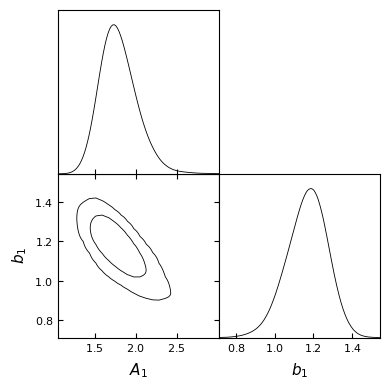

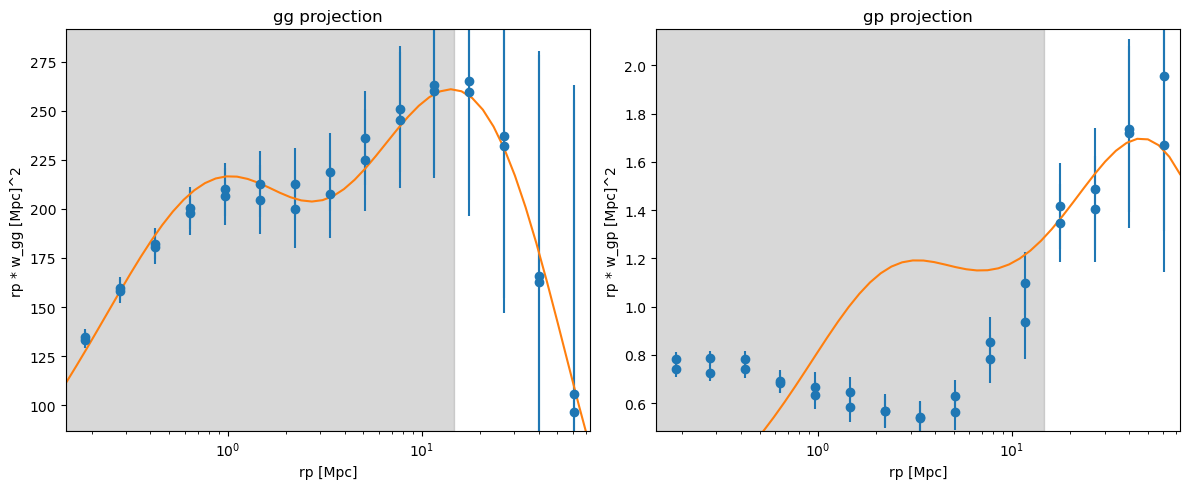

In [30]:
best_fit_paramsg, posterior_std = produce_results_for_input_data(
    redshift_idx=0,
    r_data_list=rp_redshift_list_colibre,
    data_list=projections_redshift_list_colibre,
    r_model_list=rp_redshift_list_model,
    model_list=projections_redshift_list_model,
    cov_list=projections_cov_redshift_list_colibre_padded,
    fitting_range=[10/cosmo_dict['h'], 50/cosmo_dict['h']],
    projection_type_list=['gg', 'gp'],
    renormalise_input=True,
    chi2_from_svd=True,
    n_jk=125,
)

plot_best_fit_vs_data(
    redshift_idx=0,
    best_fit_paramsg=best_fit_paramsg,
    r_redshift_list_data=rp_redshift_list_colibre,
    measurement_redshift_list_data=projections_redshift_list_colibre,
    measurement_cov_redshift_list_data=projections_cov_redshift_list_colibre,
    r_redshift_list_model=rp_redshift_list_model,
    measurement_redshift_list_model=projections_redshift_list_model,
    fitting_range=[10/cosmo_dict['h'], 50/cosmo_dict['h']],
    r_scaling_for_plot=1
)


## Multipole example

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 20     | 1        | 4        | 32900    | N/A    | 10024 | -162.52  
{'A_IA': np.float64(0.8790599676793311), 'b_g': np.float64(1.7457042769883213)}
[0.05528186 0.06043274]
Removed no burn in
/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/mcmc_output/colibre_IA_redshift0.0.txt
Removed no burn in


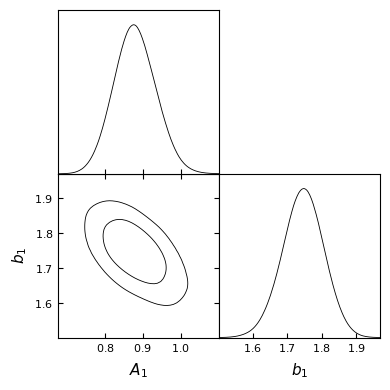

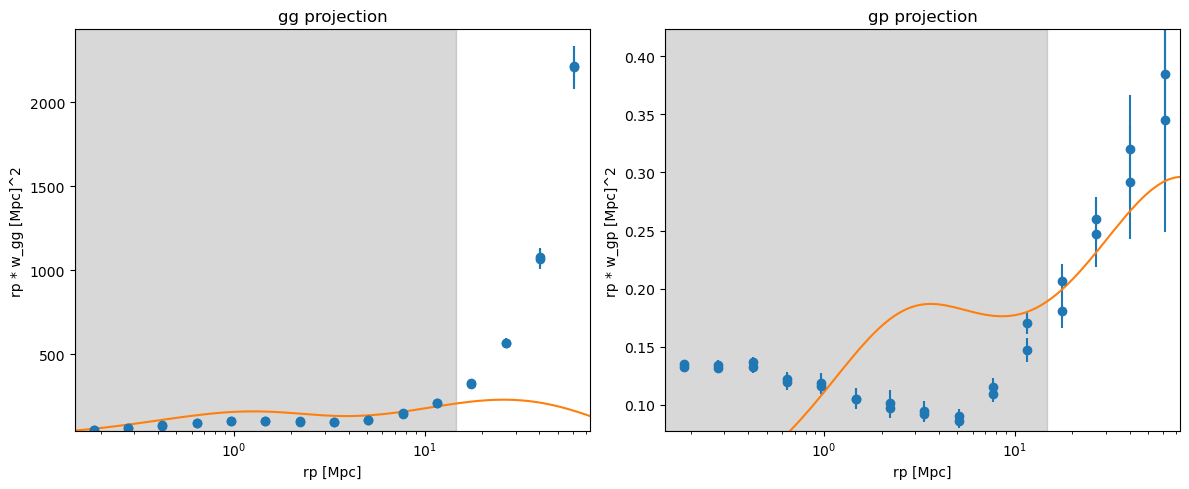

In [31]:
best_fit_paramsg, posterior_std = produce_results_for_input_data(
    redshift_idx=0,
    r_data_list=rp_redshift_list_colibre,
    data_list=multipoles_redshift_list_colibre,
    r_model_list=r_redshift_list_model,
    model_list=multipoles_redshift_list_model,
    cov_list=multipoles_cov_redshift_list_colibre_padded,
    fitting_range=[10/cosmo_dict['h'], 50/cosmo_dict['h']],
    projection_type_list=['gg', 'gp'],
    renormalise_input=True,
    chi2_from_svd=True,
    n_jk=125,
)

plot_best_fit_vs_data(
    redshift_idx=0,
    best_fit_paramsg=best_fit_paramsg,
    r_redshift_list_data=r_redshift_list_colibre,
    measurement_redshift_list_data=multipoles_redshift_list_colibre,
    measurement_cov_redshift_list_data=multipoles_cov_redshift_list_colibre,
    r_redshift_list_model=r_redshift_list_model,
    measurement_redshift_list_model=multipoles_redshift_list_model,
    fitting_range=[10/cosmo_dict['h'], 50/cosmo_dict['h']],
    r_scaling_for_plot=2
)

# Fit for A_IA * b_g from g+ only

### Projections

In [ ]:
from nautilus import Prior, Sampler

fitting_range = [6/cosmo_dict['h'], 50/cosmo_dict['h']]  # [Mpc]
redshift_idx = 0

amplitude_list = []
amplitude_err_list = []
chi2_list = []
for redshift_idx in range(len(redshift_list)):
    logger.info(f'Fitting redshift {redshift_list[redshift_idx]:.1f}...')
    amplitude, amplitude_err, chi2 = fitterHandler.fit_Aia_bg_to_data(
        r_data = rp_redshift_list_data[redshift_idx][1], 
        data = projections_redshift_list_data[redshift_idx][1], 
        r_model = rp_redshift_list_model[redshift_idx][1],
        model = projections_redshift_list_model[redshift_idx][1],
        cov = projections_cov_redshift_list_data[redshift_idx][1],
        fitting_range=fitting_range, 
        use_SVD=True,
        n_jk=125,
        return_chi2=True,
        include_Hartlap_correction=False,
    )
    logger.info(f'--------------------------------')

    amplitude_list.append(amplitude)
    amplitude_err_list.append(amplitude_err)
    chi2_list.append(chi2)

results_array = np.array([
    redshift_list,
    amplitude_list,
    amplitude_err_list,
    chi2_list,
]).T

np.savetxt(
    '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/IA_fitting_results_colibre_wgp_only.txt',
    results_array,
    header='redshift A_IA*b_g A_IA*b_g_err chi2_reduced',
)

2025-12-01 16:46:14,788 - __main__ - INFO - Fitting redshift 0.0...
2025-12-01 16:46:14,791 - __main__ - INFO - Points used for fitting: 10
2025-12-01 16:46:14,795 - __main__ - INFO - Fitted scaling: A_IA*b_g = 1.9231307731030969+-0.1555712338340777
2025-12-01 16:46:14,797 - __main__ - INFO - Reduced chi2: 0.92258115270289
2025-12-01 16:46:14,799 - __main__ - INFO - --------------------------------
2025-12-01 16:46:14,800 - __main__ - INFO - Fitting redshift 0.5...
2025-12-01 16:46:14,803 - __main__ - INFO - Points used for fitting: 9
2025-12-01 16:46:14,805 - __main__ - INFO - Fitted scaling: A_IA*b_g = 3.5541434579221867+-0.4298289013800789
2025-12-01 16:46:14,807 - __main__ - INFO - Reduced chi2: 0.42249065126419194
2025-12-01 16:46:14,810 - __main__ - INFO - --------------------------------
2025-12-01 16:46:14,811 - __main__ - INFO - Fitting redshift 1.0...
2025-12-01 16:46:14,814 - __main__ - INFO - Points used for fitting: 7
2025-12-01 16:46:14,817 - __main__ - INFO - Fitted scal

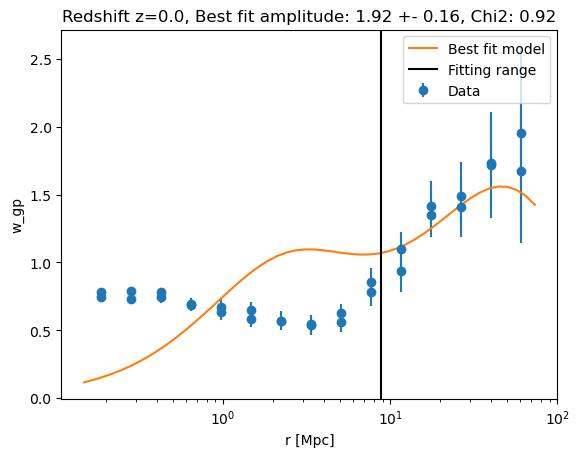

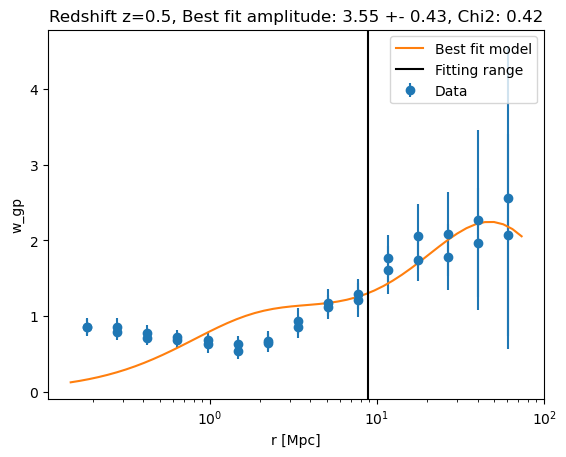

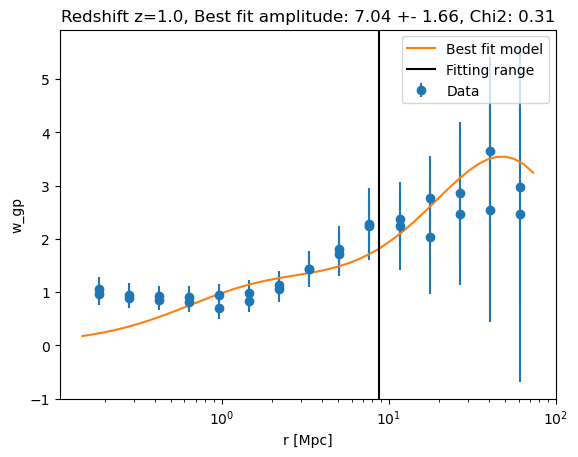

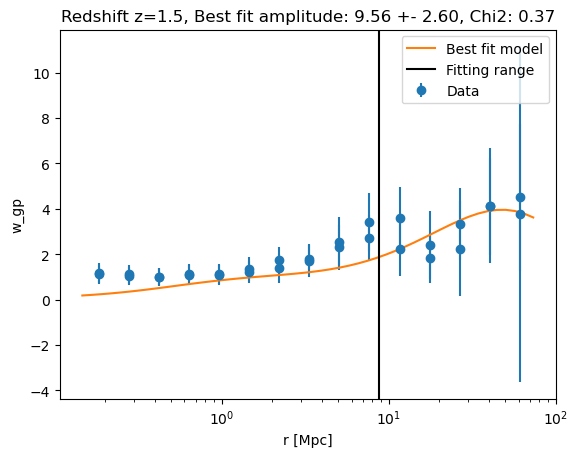

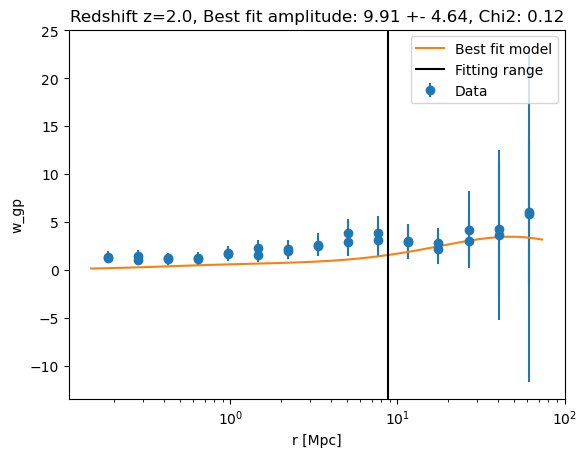

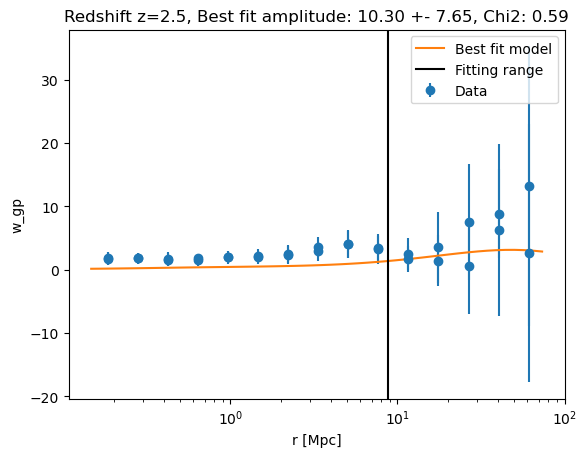

In [133]:
for redshift_idx in range(len(redshift_list)):
    plt.errorbar(
        rp_redshift_list_data[redshift_idx][1], 
        rp_redshift_list_data[redshift_idx][1]*projections_redshift_list_data[redshift_idx][1],
        yerr=np.sqrt(np.diag(projections_cov_redshift_list_data[redshift_idx][1]))*rp_redshift_list_data[redshift_idx][1],
        fmt='o', 
        label='Data'
    )
    plt.plot(rp_redshift_list_model[redshift_idx][1], rp_redshift_list_model[redshift_idx][1]*projections_redshift_list_model[redshift_idx][1]*amplitude_list[redshift_idx], '-', label='Best fit model')
    plt.axvline(fitting_range[0], color='black', alpha=1, label='Fitting range')
    plt.xlabel('r [Mpc]')
    plt.ylabel('w_gp')
    plt.xscale('log')
    plt.title(f'Redshift z={redshift_list[redshift_idx]:.1f}, Best fit amplitude: {amplitude_list[redshift_idx]:.2f} +- {amplitude_err_list[redshift_idx]:.2f}, Chi2: {chi2_list[redshift_idx]:.2f}')
    plt.legend()
    plt.show()
    plt.close()


### Multipole

In [13]:
from nautilus import Prior, Sampler

fitting_range = [10/cosmo_dict['h'], 50/cosmo_dict['h']]  # [Mpc]

amplitude_list = []
amplitude_err_list = []
chi2_list = []
for redshift_idx in range(len(redshift_list)):
    logger.info(f'Fitting redshift {redshift_list[redshift_idx]:.1f}...')
    amplitude, amplitude_err, chi2 = fitterHandler.fit_Aia_bg_to_data(
        r_data = r_redshift_list_data[redshift_idx][1], 
        data = multipoles_redshift_list_data[redshift_idx][1], 
        r_model = r_redshift_list_model[redshift_idx][1],
        model = multipoles_redshift_list_model[redshift_idx][1],
        cov = multipoles_cov_redshift_list_data[redshift_idx][1],
        fitting_range=fitting_range, 
        use_SVD=True,
        n_jk=125,
        return_chi2=True,
        include_Hartlap_correction=False,
    )
    logger.info(f'--------------------------------')

    amplitude_list.append(amplitude)
    amplitude_err_list.append(amplitude_err)
    chi2_list.append(chi2)

results_array = np.array([
    redshift_list,
    amplitude_list,
    amplitude_err_list,
    chi2_list,
]).T

np.savetxt(
    '/home/dneup16/leiden_phd/scripts/results/IA_redshift_dependency_simulations/IA_fitting_results_colibre_xigp_only.txt',
    results_array,
    header='redshift A_IA*b_g A_IA*b_g_err chi2_reduced',
)

2025-12-01 16:47:54,017 - __main__ - INFO - Fitting redshift 0.0...
2025-12-01 16:47:54,020 - __main__ - INFO - Points used for fitting: 8
2025-12-01 16:47:54,022 - __main__ - INFO - Fitted scaling: A_IA*b_g = 1.5314874697451146+-0.08041752742593704
2025-12-01 16:47:54,022 - __main__ - INFO - Reduced chi2: 1.1817363157612812
2025-12-01 16:47:54,023 - __main__ - INFO - --------------------------------
2025-12-01 16:47:54,023 - __main__ - INFO - Fitting redshift 0.5...
2025-12-01 16:47:54,024 - __main__ - INFO - Points used for fitting: 7
2025-12-01 16:47:54,026 - __main__ - INFO - Fitted scaling: A_IA*b_g = 3.2766883132326945+-0.34062416435423754
2025-12-01 16:47:54,027 - __main__ - INFO - Reduced chi2: 0.6655779398828903
2025-12-01 16:47:54,029 - __main__ - INFO - --------------------------------
2025-12-01 16:47:54,030 - __main__ - INFO - Fitting redshift 1.0...
2025-12-01 16:47:54,034 - __main__ - INFO - Points used for fitting: 7
2025-12-01 16:47:54,035 - __main__ - INFO - Fitted sc

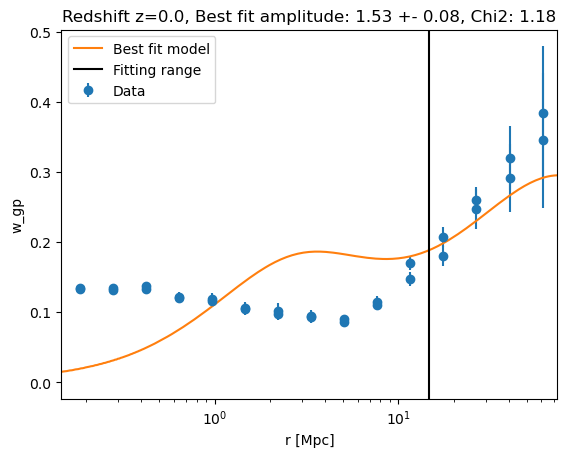

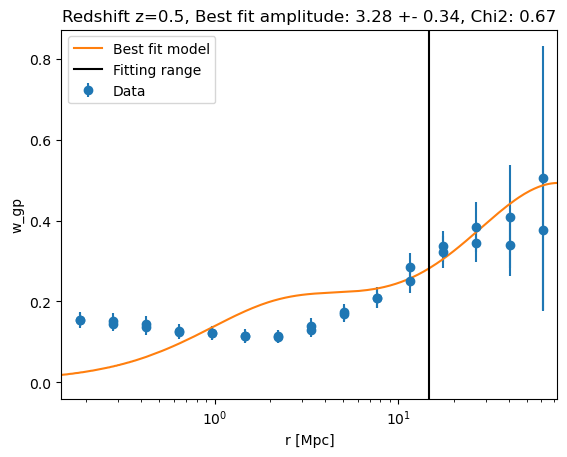

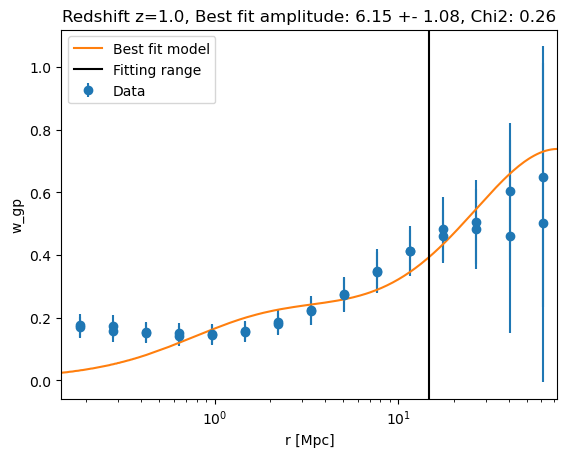

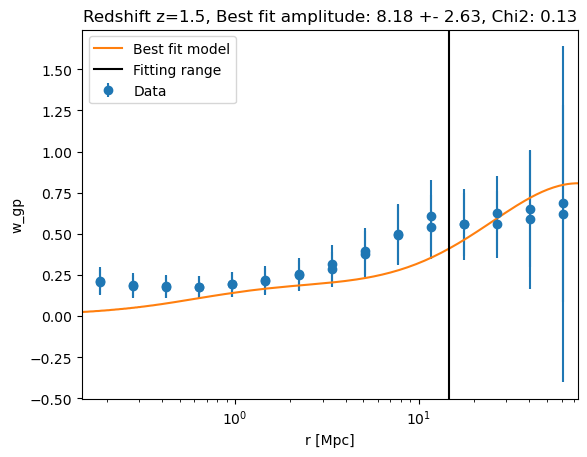

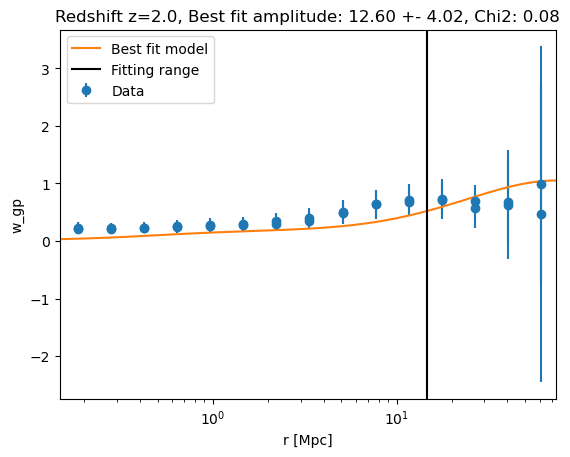

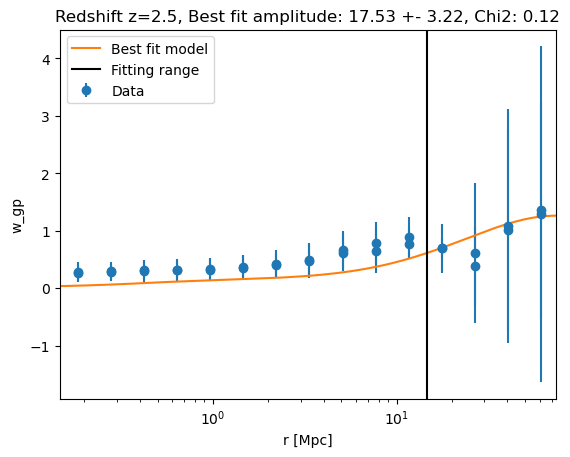

In [16]:
for redshift_idx in range(len(redshift_list)):
    plt.errorbar(
        r_redshift_list_data[redshift_idx][1], 
        r_redshift_list_data[redshift_idx][1]**2*multipoles_redshift_list_data[redshift_idx][1],
        yerr=np.sqrt(np.diag(multipoles_cov_redshift_list_data[redshift_idx][1]))*r_redshift_list_data[redshift_idx][1]**2,
        fmt='o', 
        label='Data'
    )
    plt.plot(r_redshift_list_model[redshift_idx][1], 
             r_redshift_list_model[redshift_idx][1]**2*multipoles_redshift_list_model[redshift_idx][1]*amplitude_list[redshift_idx], 
             '-', 
             label='Best fit model')
    plt.axvline(fitting_range[0], color='black', alpha=1, label='Fitting range')
    plt.xlabel('r [Mpc]')
    plt.ylabel('w_gp')
    plt.xscale('log')
    plt.xlim(rmin, rmax)
    plt.title(f'Redshift z={redshift_list[redshift_idx]:.1f}, Best fit amplitude: {amplitude_list[redshift_idx]:.2f} +- {amplitude_err_list[redshift_idx]:.2f}, Chi2: {chi2_list[redshift_idx]:.2f}')
    plt.legend()
    plt.show()
    plt.close()


# Check with Romain

In [90]:
import DR1_WL_3.model_NRV
import importlib
importlib.reload(DR1_WL_3.model_NRV)
import DR1_WL_3.model_NRV as md2

import pyccl as ccl
import numpy as np

In [99]:
import pyccl as ccl
import numpy as np

redshift_idx = 0
logger.info(f'Looking at redshift {redshift_list[redshift_idx]}')
cosmology = [cosmo_dict['Omega_c'],cosmo_dict['Omega_b'],cosmo_dict['m_nu'],cosmo_dict['A_s'],cosmo_dict['n_s'],cosmo_dict['h'],redshift_list[redshift_idx]]

model = md2.TwoPointModel(
    cosmology,
    config='NLA',
    computation=['WGG_WEDGE', 'WGP_WEDGE'],
    do_rsd=False,
    pimax=pimax*cosmo_dict['h'],
    bin_avg=False,
    bin_factor=20,
    evolve_bias=False,
    rp_min_wedge=0.01,
    n_mu_wedge=101,
)

s = np.geomspace(0.1,50,51)
A1 = 1
b1 = 1
xi_gi_multipole_romain_wedged = model.compute_xi_gi_wedge_quadrupole(s,b1,0.,A1,0.,0.)
xi_gg_multipole_romain_wedged = model.compute_xi_gg_wedge_monopole(s,b1,0.,A1,0.,0.)
w_gi_romain = model.compute_wgp(s,b1,0.,A1,0.,0.)/cosmo_dict['h']
w_gg_romain = model.compute_wgg(s,b1,0.,A1,0.,0.)/cosmo_dict['h']
s /= cosmo_dict['h']

2025-12-02 09:53:15,890 - __main__ - INFO - Looking at redshift 0
INFO:__main__:Looking at redshift 0


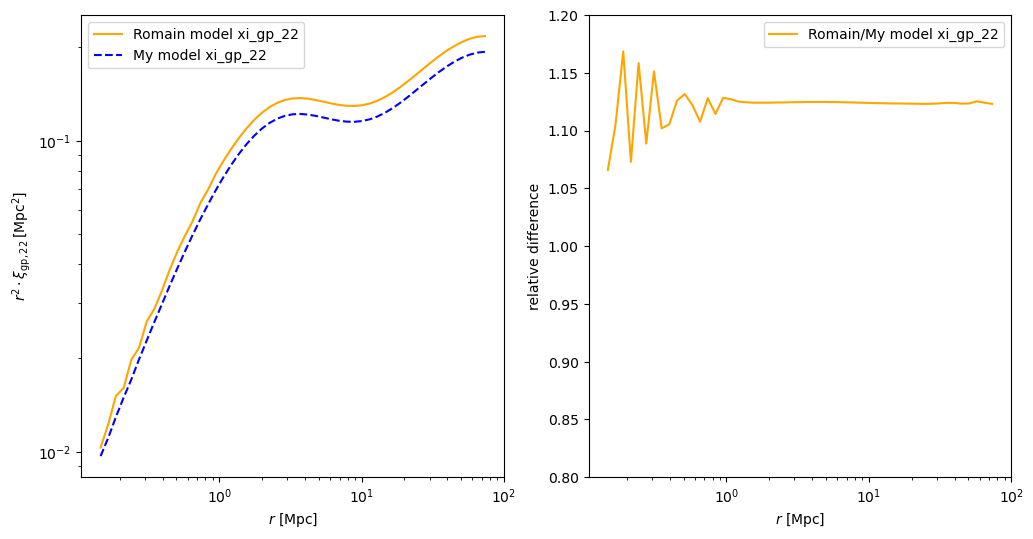

In [100]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
s_me = r_redshift_list_model[redshift_idx][1]
xi_gi_me = multipoles_redshift_list_model[redshift_idx][1]

# Project r_wgp to s values
xi_gi_interpolated = np.interp(s, s_me, xi_gi_me)

ax[0].loglog(s, s**2*xi_gi_multipole_romain_wedged, label='Romain model xi_gp_22', color='orange')
ax[0].loglog(s, s**2*xi_gi_interpolated, label='My model xi_gp_22', color='blue', linestyle='--')
ax[0].set_xlabel(r"$r$ [Mpc]")
ax[0].set_ylabel(r"$r^2\cdot\xi_{\rm gp, 22}\, [\mathrm{Mpc}^2]$")
ax[0].legend()

# Plot relative difference
ax[1].semilogx(s, xi_gi_multipole_romain_wedged/(xi_gi_interpolated), label='Romain/My model xi_gp_22', color='orange')
ax[1].set_xlabel(r"$r$ [Mpc]")
ax[1].set_ylabel(r"relative difference")
ax[1].legend()
ax[1].set_ylim(0.8, 1.2)

plt.show()
plt.close()

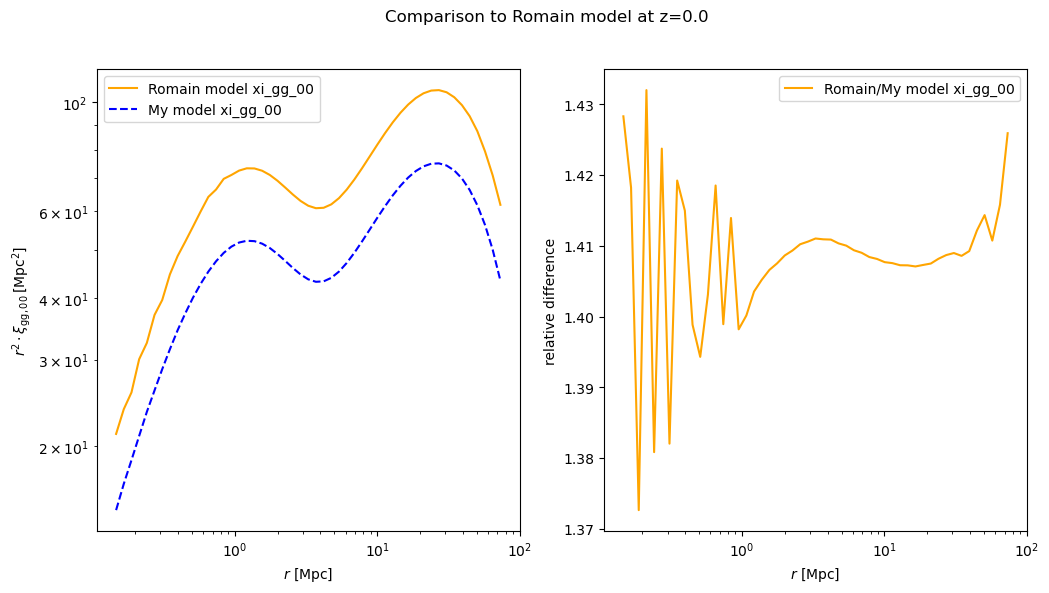

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
s_me = r_redshift_list_model[redshift_idx][0]
xi_gg_me = multipoles_redshift_list_model[redshift_idx][0]

# Project r_wgp to s values
xi_gg_interpolated = np.interp(s, s_me, xi_gg_me)

ax[0].loglog(s, s**2*xi_gg_multipole_romain_wedged, label='Romain model xi_gg_00', color='orange')
ax[0].loglog(s, s**2*xi_gg_interpolated, label='My model xi_gg_00', color='blue', linestyle='--')
ax[0].set_xlabel(r"$r$ [Mpc]")
ax[0].set_ylabel(r"$r^2\cdot\xi_{\rm gg, 00}\, [\mathrm{Mpc}^2]$")
ax[0].legend()

# Plot relative difference
ax[1].semilogx(s, xi_gg_multipole_romain_wedged/(xi_gg_interpolated), label='Romain/My model xi_gg_00', color='orange')
ax[1].set_xlabel(r"$r$ [Mpc]")
ax[1].set_ylabel(r"relative difference")
ax[1].legend()
# ax[1].set_ylim(0.8, 1.2)

plt.suptitle('Comparison to Romain model at z={:.1f}'.format(redshift_list[redshift_idx]))
plt.show()
plt.close()

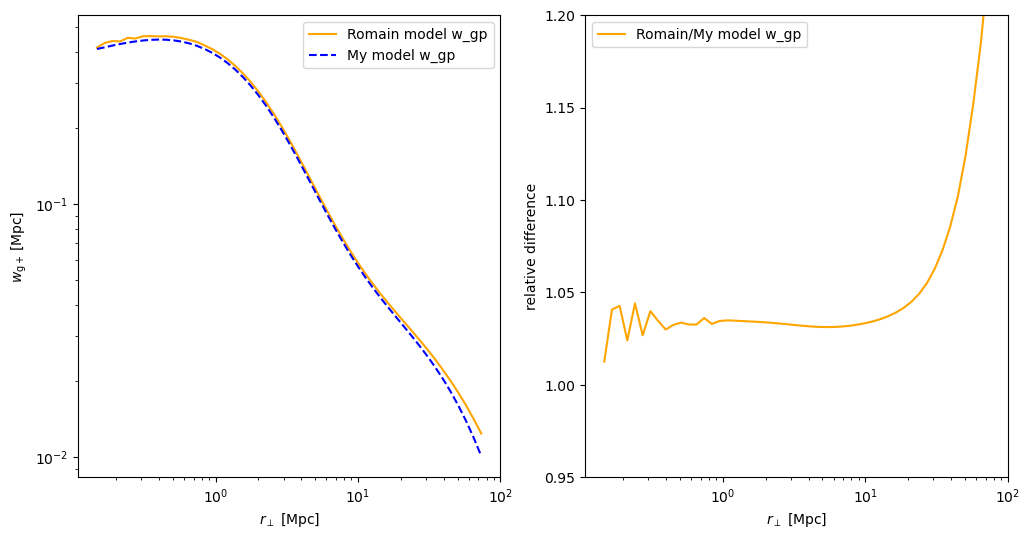

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
s_me = rp_redshift_list_model[redshift_idx][1]
w_gp = projections_redshift_list_model[redshift_idx][1]

# Project r_wgp to s values
w_gp_interpolated = np.interp(s, s_me, w_gp)

ax[0].loglog(s, w_gi_romain, label='Romain model w_gp', color='orange')
ax[0].loglog(s, w_gp_interpolated*A1*b1, label='My model w_gp', color='blue', linestyle='--')
ax[0].set_xlabel(r"$r_\perp$ [Mpc]")
ax[0].set_ylabel(r"$w_{\rm g+}\,[\mathrm{Mpc}]$")
ax[0].legend()

# Plot relative difference
ax[1].semilogx(s, w_gi_romain/(w_gp_interpolated*A1*b1), label='Romain/My model w_gp', color='orange')
ax[1].set_xlabel(r"$r_\perp$ [Mpc]")
ax[1].set_ylabel(r"relative difference")
ax[1].legend()
ax[1].set_ylim(0.95, 1.2)

plt.show()
plt.close()


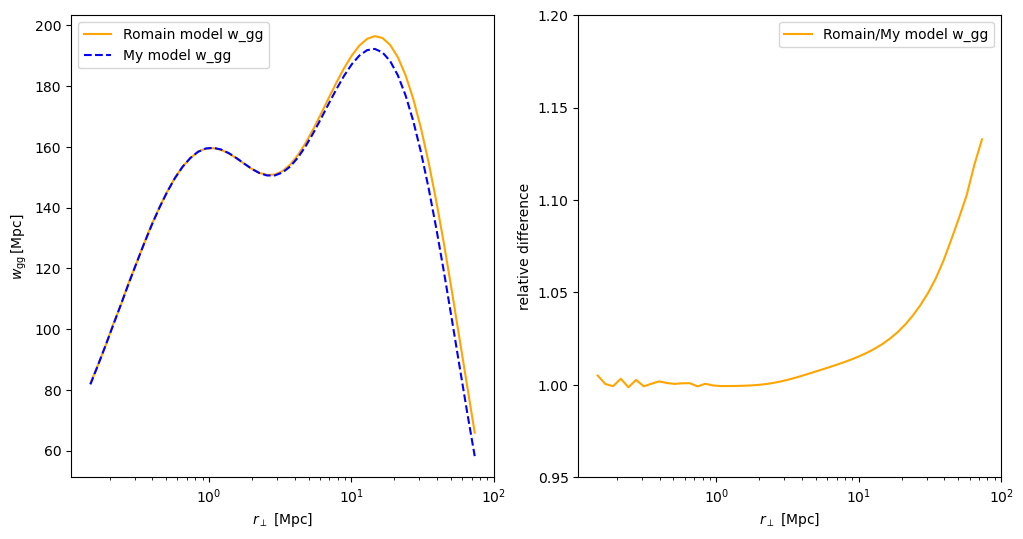

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
s_me = rp_redshift_list_model[redshift_idx][0]
w_gg = projections_redshift_list_model[redshift_idx][0]

# Project r_wgp to s values
w_gg_interpolated = np.interp(s, s_me, w_gg)

ax[0].semilogx(s, s*w_gg_romain, label='Romain model w_gg', color='orange')
ax[0].semilogx(s, s*w_gg_interpolated, label='My model w_gg', color='blue', linestyle='--')
ax[0].set_xlabel(r"$r_\perp$ [Mpc]")
ax[0].set_ylabel(r"$w_{\rm gg}\,[\mathrm{Mpc}]$")
ax[0].legend()

# Plot relative difference
ax[1].semilogx(s, w_gg_romain/(w_gg_interpolated*A1*b1), label='Romain/My model w_gg', color='orange')
ax[1].set_xlabel(r"$r_\perp$ [Mpc]")
ax[1].set_ylabel(r"relative difference")
ax[1].legend()
ax[1].set_ylim(0.95, 1.2)

plt.show()
plt.close()